In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb
from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [2]:
data_prefix = "../0_data/processed_data/"
model_types = ['RF', 'XGB', 'LGB']
non_feature_cols = ['SMILES', 'MP', 'Type', 'MP']

In [3]:

def model_development(data, non_feature_cols, model_type):

    X = data.drop(columns=non_feature_cols)
    y = data['MP'].values
    strat_labels = data['Ro5'].values

    # Precompute folds stratified on Ro5 label (not continuous MP)
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    folds = list(skf.split(X, strat_labels))

    # ── Helper: run 10-fold CV for a given model instance ─────────────
    def run_cv(model_instance):
        fold_rmses = []
        for train_idx, val_idx in folds:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            model_instance.fit(X_train, y_train)
            preds = model_instance.predict(X_val)
            fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
        return fold_rmses

    # ── Model + search space definitions ──────────────────────────────
    if model_type == 'RF':
        default_model = RandomForestRegressor(random_state=42, n_jobs=-1)
        base_model    = RandomForestRegressor(random_state=42, n_jobs=-1)
        search_space  = {
            'n_estimators':      Integer(50, 500),
            'max_depth':         Integer(3,    20),
            'min_samples_split': Integer(2,    20),
            'min_samples_leaf':  Integer(1,    10),
            'max_features':      Real(0.1, 1.0),
        }

    elif model_type == 'LGB':
        default_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
        base_model    = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
        search_space  = {
            'num_leaves':        Integer(20,   300),
            'max_depth':         Integer(3,    12),
            'learning_rate':     Real(0.01, 0.3,   prior='log-uniform'),
            'n_estimators':      Integer(50, 500),
            'min_child_samples': Integer(10,   50),
            'subsample':         Real(0.6, 1.0),
            'colsample_bytree':  Real(0.4, 1.0),
            'reg_alpha':         Real(1e-5, 10.0,  prior='log-uniform'),
            'reg_lambda':        Real(1e-5, 10.0,  prior='log-uniform'),
        }

    elif model_type == 'XGB':
        default_model = xgb.XGBRegressor(random_state=42, n_jobs=-1,
                                          tree_method='hist', verbosity=0)
        base_model    = xgb.XGBRegressor(random_state=42, n_jobs=-1,
                                          tree_method='hist', verbosity=0)
        search_space  = {
            'n_estimators':      Integer(50, 500),
            'max_depth':         Integer(3,    12),
            'learning_rate':     Real(0.01, 0.3,  prior='log-uniform'),
            'subsample':         Real(0.6, 1.0),
            'colsample_bytree':  Real(0.4, 1.0),
            'reg_alpha':         Real(1e-5, 10.0, prior='log-uniform'),
            'reg_lambda':        Real(1e-5, 10.0, prior='log-uniform'),
            'min_child_weight':  Integer(1,   10),
        }

    else:
        raise ValueError(f"model_type must be 'RF', 'LGB', or 'XGB'; got '{model_type}'")

    # ── Trial 0: default hyperparameters ──────────────────────────────
    trial_results = {}
    fold_rmses_0 = run_cv(default_model)
    mean_0 = float(np.mean(fold_rmses_0))
    std_0  = float(np.std(fold_rmses_0))
    trial_results[0] = {'fold_rmses': fold_rmses_0, 'mean_rmse': mean_0, 'std_rmse': std_0}
    print(f"Trial  0 (default) | mean RMSE: {mean_0:.4f} ± {std_0:.4f}")

    # ── Trials 1-20: BayesSearchCV ────────────────────────────────────
    # Pass precomputed folds as cv so BayesSearchCV never calls
    # StratifiedKFold.split(X, y) with a continuous y (which would error).
    opt = BayesSearchCV(
        base_model,
        search_space,
        n_iter=20,
        cv=folds,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=1,
        refit=True,
    )
    opt.fit(X, y)

    # Extract per-trial fold RMSEs from cv_results_ (negate the neg-RMSE scores)
    n_splits = len(folds)
    for i in range(20):
        fold_rmses = [-opt.cv_results_[f'split{s}_test_score'][i] for s in range(n_splits)]
        mean_rmse  = float(np.mean(fold_rmses))
        std_rmse   = float(np.std(fold_rmses))
        trial_results[i + 1] = {
            'fold_rmses': fold_rmses,
            'mean_rmse':  mean_rmse,
            'std_rmse':   std_rmse,
        }
        print(f"Trial {i+1:>2d} | mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

    # ── Best params & model (BayesSearchCV already refits on all data) ─
    best_model_info = {
        'best_params': opt.best_params_,
        'model':       opt.best_estimator_,
    }

    return trial_results, best_model_info


In [4]:
model_development_results_dict = {}
for model in model_types:

    data = pd.read_parquet(data_prefix + f"data_with_selected_features_{model}_scaled.parquet").head(100)
    print(f"\n=== Model: {model} ===")
    # print the number of data and features
    print(f"Dataset shape: {data.shape} (n_samples={data.shape[0]}, n_features={data.shape[1] - len(non_feature_cols)})")
    trial_results, best_model_info = model_development(data, non_feature_cols, model_type=model)
    model_development_results_dict[model] = {
        'trial_results': trial_results,
        'best_model_info': best_model_info,
    }

# picke save the model_development_results_dict
import pickle
with open('model_development_results_dict.pkl', 'wb') as f:
    pickle.dump(model_development_results_dict, f)



=== Model: RF ===
Dataset shape: (100, 67) (n_samples=100, n_features=63)


/Users/zeqing/opt/anaconda3/envs/LA/lib/python3.6/site-packages/sklearn/model_selection/_split.py:668: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


Trial  0 (default) | mean RMSE: 50.1303 ± 16.7561
Trial  1 | mean RMSE: 52.5365 ± 16.6581
Trial  2 | mean RMSE: 51.6298 ± 16.9019
Trial  3 | mean RMSE: 50.8909 ± 16.6270
Trial  4 | mean RMSE: 53.2408 ± 16.0650
Trial  5 | mean RMSE: 52.5169 ± 16.4595
Trial  6 | mean RMSE: 49.9724 ± 16.9588
Trial  7 | mean RMSE: 51.5231 ± 16.8559
Trial  8 | mean RMSE: 51.6254 ± 17.0623
Trial  9 | mean RMSE: 52.5538 ± 16.3965
Trial 10 | mean RMSE: 52.3419 ± 16.5495
Trial 11 | mean RMSE: 50.0794 ± 17.0983
Trial 12 | mean RMSE: 50.5215 ± 16.9217
Trial 13 | mean RMSE: 49.7981 ± 17.1045
Trial 14 | mean RMSE: 50.4558 ± 16.3386
Trial 15 | mean RMSE: 50.0383 ± 17.3156
Trial 16 | mean RMSE: 49.8125 ± 17.2057
Trial 17 | mean RMSE: 49.8011 ± 17.1826
Trial 18 | mean RMSE: 49.7589 ± 17.2034
Trial 19 | mean RMSE: 51.3588 ± 17.3965
Trial 20 | mean RMSE: 49.8125 ± 17.2057

=== Model: XGB ===
Dataset shape: (100, 57) (n_samples=100, n_features=53)


/Users/zeqing/opt/anaconda3/envs/LA/lib/python3.6/site-packages/sklearn/model_selection/_split.py:668: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


Trial  0 (default) | mean RMSE: 49.0143 ± 12.0196
Trial  1 | mean RMSE: 46.6539 ± 11.0641
Trial  2 | mean RMSE: 52.6373 ± 11.0834
Trial  3 | mean RMSE: 47.2825 ± 9.8249
Trial  4 | mean RMSE: 48.0207 ± 12.1309
Trial  5 | mean RMSE: 48.5650 ± 12.0339
Trial  6 | mean RMSE: 44.9831 ± 12.3322
Trial  7 | mean RMSE: 50.5662 ± 9.7824
Trial  8 | mean RMSE: 51.2514 ± 10.4864
Trial  9 | mean RMSE: 46.5641 ± 11.8925
Trial 10 | mean RMSE: 46.8700 ± 10.4924
Trial 11 | mean RMSE: 99.1054 ± 23.3893
Trial 12 | mean RMSE: 45.1358 ± 12.3265
Trial 13 | mean RMSE: 46.5419 ± 12.7489
Trial 14 | mean RMSE: 46.4582 ± 10.5695
Trial 15 | mean RMSE: 70.4299 ± 21.4277
Trial 16 | mean RMSE: 82.9724 ± 22.6557
Trial 17 | mean RMSE: 46.2408 ± 12.3765
Trial 18 | mean RMSE: 54.6806 ± 17.0156
Trial 19 | mean RMSE: 53.6356 ± 15.2284
Trial 20 | mean RMSE: 46.2678 ± 13.9909

=== Model: LGB ===
Dataset shape: (100, 112) (n_samples=100, n_features=108)


/Users/zeqing/opt/anaconda3/envs/LA/lib/python3.6/site-packages/sklearn/model_selection/_split.py:668: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


Trial  0 (default) | mean RMSE: 53.4952 ± 15.8132
Trial  1 | mean RMSE: 54.2105 ± 14.1171
Trial  2 | mean RMSE: 64.5213 ± 17.5430
Trial  3 | mean RMSE: 51.5080 ± 12.6398
Trial  4 | mean RMSE: 56.5645 ± 16.4127
Trial  5 | mean RMSE: 51.5881 ± 14.9302
Trial  6 | mean RMSE: 52.3714 ± 15.9417
Trial  7 | mean RMSE: 64.7145 ± 18.9666
Trial  8 | mean RMSE: 55.8539 ± 15.3416
Trial  9 | mean RMSE: 51.7020 ± 13.6610
Trial 10 | mean RMSE: 52.7413 ± 13.9035
Trial 11 | mean RMSE: 52.1502 ± 14.6933
Trial 12 | mean RMSE: 51.7703 ± 14.1144
Trial 13 | mean RMSE: 55.1015 ± 12.2012
Trial 14 | mean RMSE: 49.4216 ± 13.8971
Trial 15 | mean RMSE: 49.6327 ± 13.1096
Trial 16 | mean RMSE: 49.5514 ± 13.2350
Trial 17 | mean RMSE: 53.3037 ± 15.5481
Trial 18 | mean RMSE: 50.0135 ± 12.8897
Trial 19 | mean RMSE: 51.7049 ± 14.4013
Trial 20 | mean RMSE: 50.0414 ± 12.7537


In [8]:
model_development_results_dict

{'RF': {'trial_results': {0: {'fold_rmses': [78.89326444190277,
     55.221535470548076,
     54.23475484733014,
     67.06245095767079,
     39.1878404173412,
     29.85645210042546,
     28.544213676330273,
     68.68157715446698,
     46.77437650867193,
     32.84614641856789],
    'mean_rmse': 50.13026119932555,
    'std_rmse': 16.756051481327436},
   1: {'fold_rmses': [86.59103627408943,
     51.302040855151176,
     50.81242478738019,
     63.97408713455525,
     39.72535876322593,
     30.72551753791055,
     38.35434830979709,
     74.24010961643346,
     49.75829394249595,
     39.88191856868744],
    'mean_rmse': 52.536513578972645,
    'std_rmse': 16.65805336111435},
   2: {'fold_rmses': [85.50098917411353,
     52.52817693241041,
     51.99230023553815,
     65.16163838904991,
     39.39119570736494,
     28.860797898949638,
     36.307594600234175,
     71.27321656300298,
     48.76417475570707,
     36.51799139984392],
    'mean_rmse': 51.62980756562147,
    'std_rmse': 1

In [9]:
import matplotlib.pyplot as plt

def plot_model_performance(model_development_results_dict):
    """
    Plot mean RMSE ± std as a function of HP tuning iteration.

    Parameters
    ----------
    model_development_results_dict : dict
        The trial_results dict returned by model_development().
        Keys = trial number (0 = default HP, 1-20 = BayesSearchCV iterations).
        Values = {'mean_rmse': float, 'std_rmse': float, ...}
    """
    trials     = sorted(model_development_results_dict.keys())
    mean_rmses = [model_development_results_dict[t]['mean_rmse'] for t in trials]
    std_rmses  = [model_development_results_dict[t]['std_rmse']  for t in trials]

    mean_rmses = np.array(mean_rmses)
    std_rmses  = np.array(std_rmses)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(trials, mean_rmses, marker='o', linewidth=1.5, color='steelblue', label='Mean RMSE')
    ax.fill_between(trials,
                    mean_rmses - std_rmses,
                    mean_rmses + std_rmses,
                    alpha=0.25, color='steelblue', label='± 1 std')

    # Mark trial 0 (default HP) distinctly
    ax.axvline(x=0, color='grey', linestyle='--', linewidth=1, label='Default HP (trial 0)')

    # Highlight best trial
    best_trial = trials[int(np.argmin(mean_rmses))]
    best_rmse  = min(mean_rmses)
    ax.scatter([best_trial], [best_rmse], color='red', zorder=5,
               label=f'Best (trial {best_trial}, RMSE={best_rmse:.4f})')

    ax.set_xlabel('HP Tuning Iteration', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title('Model Performance vs. HP Tuning Iteration', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()



=== Performance plot for RF ===


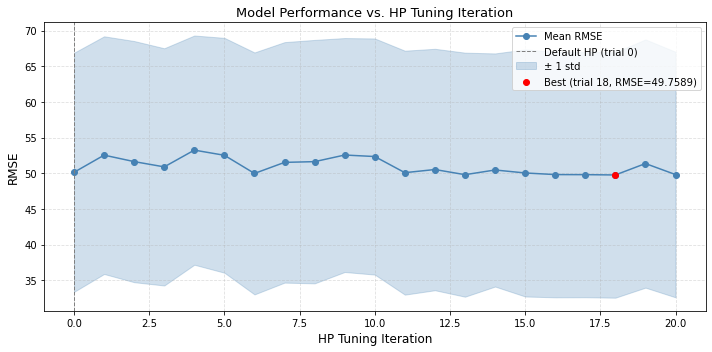


=== Performance plot for XGB ===


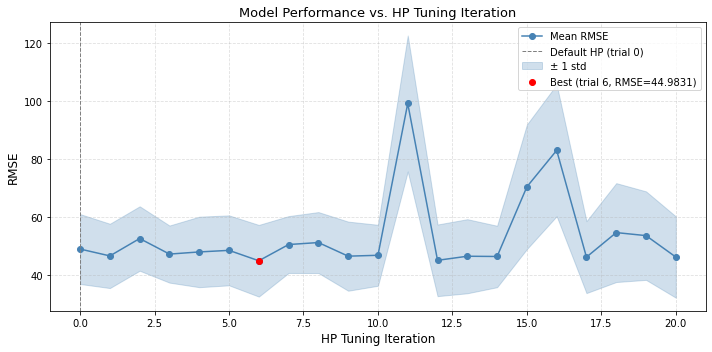


=== Performance plot for LGB ===


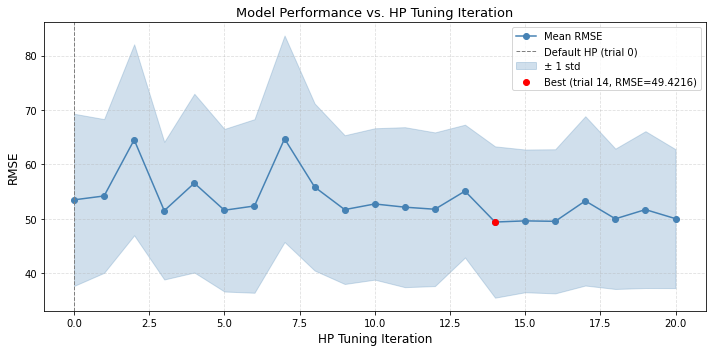

In [10]:
for model in model_types:
    print(f"\n=== Performance plot for {model} ===")
    plot_model_performance(model_development_results_dict[model]['trial_results'])